In [1]:
import chipwhisperer as cw
import chipwhisperer.common.results.glitch as glitch
import numpy as np
import time

# --- USER CONFIGURATION ---
# *** IMPORTANT:BITSTREAM PATH ***
BITSTREAM_FILEPATH = r'C:\Users\sbista\ChipWhisperer\chipwhisperer\firmware\fpgas\aes\vivado\cw305_aes.runs\impl_100t\cw305_top.bit'

# Set a fixed key and plaintext for consistent testing
KEY = bytearray([0x2B, 0x7E, 0x15, 0x16, 0x28, 0xAE, 0xD2, 0xA6, 0xAB, 0xF7, 0x15, 0x88, 0x09, 0xCF, 0x4F, 0x3C])
PLAINTEXT = bytearray([0x5C, 0x69, 0x2F, 0x91, 0x03, 0xB2, 0x30, 0x29, 0x14, 0xD7, 0xE5, 0x55, 0xE4, 0xDC, 0xEE, 0x49])
EXPECTED_CIPHERTEXT = bytearray([0x06, 0xF3, 0x6A, 0x65, 0xE8, 0xA9, 0x9F, 0xF8, 0x90, 0x7B, 0x2E, 0x5E, 0x5D, 0xDD, 0x77, 0xDE])

NUM_GLITCH_ATTEMPTS = 500 # Number of times to try glitching
NUM_NORMAL_TRACES = 10000 # Number of traces without glitch for comparison

# --- CONNECTION ---
scope = cw.scope()
target = cw.target(scope, cw.targets.CW305, bsfile=BITSTREAM_FILEPATH, force=True)

(ChipWhisperer Target WARNING|File CW305.py:591) Using default Verilog defines (C:\Users\sbista\ChipWhisperer\chipwhisperer\software\chipwhisperer/hardware/firmware/cw305/cw305_aes_defines.v); if this is not what you want, provide them via the defines_files argument


In [2]:
#newone
scope.gain.gain = 40
scope.gain.mode = "high"
scope.adc.samples = 40
scope.adc.offset = 0
scope.adc.basic_mode = "rising_edge"
scope.clock.adc_src = "clkgen_x4"
scope.clock.freq_ctr_src = "clkgen"
scope.clock.adc_phase = 175
scope.trigger.triggers = "tio4"
scope.io.tio1 = "serial_rx"
scope.io.tio2 = "serial_tx"
scope.io.hs2 = "clkgen"

#CLKGEN Settings
scope.clock.extclk_freq = 10000000
scope.clock.clkgen_mul = 5
scope.clock.clkgen_div = 48
scope.clock.clkgen_freq = 10000000


import time
for i in range(5):
    scope.clock.reset_adc()
    time.sleep(1)
    if scope.clock.adc_locked:
        break 
assert (scope.clock.adc_locked), "ADC failed to lock"

In [3]:
#newone
scope.gain.gain = 40
scope.gain.mode = "high"
scope.adc.samples = 40
scope.adc.offset = 0
scope.adc.basic_mode = "falling_edge"
#scope.clock.adc_src = "clkgen_x4"
#scope.clock.freq_ctr_src = "clkgen"
scope.clock.adc_phase = 175
#scope.trigger.triggers = "tio4"
#scope.io.tio1 = "serial_rx"
#scope.io.tio2 = "serial_tx"
#scope.io.hs2 = "clkgen"


import time
for i in range(5):
    scope.clock.reset_adc()
    time.sleep(1)
    if scope.clock.adc_locked:
        break 
assert (scope.clock.adc_locked), "ADC failed to lock"

In [4]:
target.set_key(KEY)
def run_aes(target, plaintext, KEY):
    target.simpleserial_write('p', plaintext)
    # The target.go() is handled by simpleserial_write for the CW305 target
    
    # Read the output from the target
    try:
        response = target.simpleserial_read('r', 16)
        if len(response) == 16:
            return response, True
        else:
            return None, False
    except Exception as e:
        print(f"Target read error: {e}")
        return None, False

In [5]:
for i in range(10):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    
    if scope.capture():
        #print("Timeout – no trigger seen")
        continue


    if ok and out != EXPECTED_CIPHERTEXT:
        print("Not Normal:", out.hex())
    else:
        print("normal",out.hex())

Not Normal: 4ee432251ee009187ab4fbf43eef6f97
Not Normal: 4ee432251ee009187ab4fbf43eef6f97
Not Normal: 4ee432251ee009187ab4fbf43eef6f97
Not Normal: 4ee432251ee009187ab4fbf43eef6f97
Not Normal: 4ee432251ee009187ab4fbf43eef6f97
Not Normal: 4ee432251ee009187ab4fbf43eef6f97
Not Normal: 4ee432251ee009187ab4fbf43eef6f97
Not Normal: 4ee432251ee009187ab4fbf43eef6f97
Not Normal: 4ee432251ee009187ab4fbf43eef6f97
Not Normal: 4ee432251ee009187ab4fbf43eef6f97


In [6]:
## --- 2. CAPTURE NORMAL TRACES ---
print("\n--- Collecting Normal Traces ---")
# Storage for the normal traces
normal_traces = []

#for i in range(NUM_NORMAL_TRACES):
for i in range(1000):
    scope.arm()
    output, success = run_aes(target, PLAINTEXT, KEY)
    
    if scope.capture():
        print(f"Timeout occurred on trace {i}")
        continue

    trace = scope.get_last_trace()
    normal_traces.append(trace)
    
    # Verify the output is the expected ciphertext
    #if output == EXPECTED_CIPHERTEXT:
        #print(f"Trace {i}: Success, Output: {output.hex()}")
    #else:
        #print(f"Trace {i}: FAIL, Output: {output.hex() if output else 'N/A'}")

    if output != EXPECTED_CIPHERTEXT:
        print(f"Trace {i}: FAIL, Output: {output.hex() if output else 'N/A'}")
        
print(f"Baseline trace collection complete. Collected {len(normal_traces)} good traces.")



--- Collecting Normal Traces ---
Baseline trace collection complete. Collected 1000 good traces.


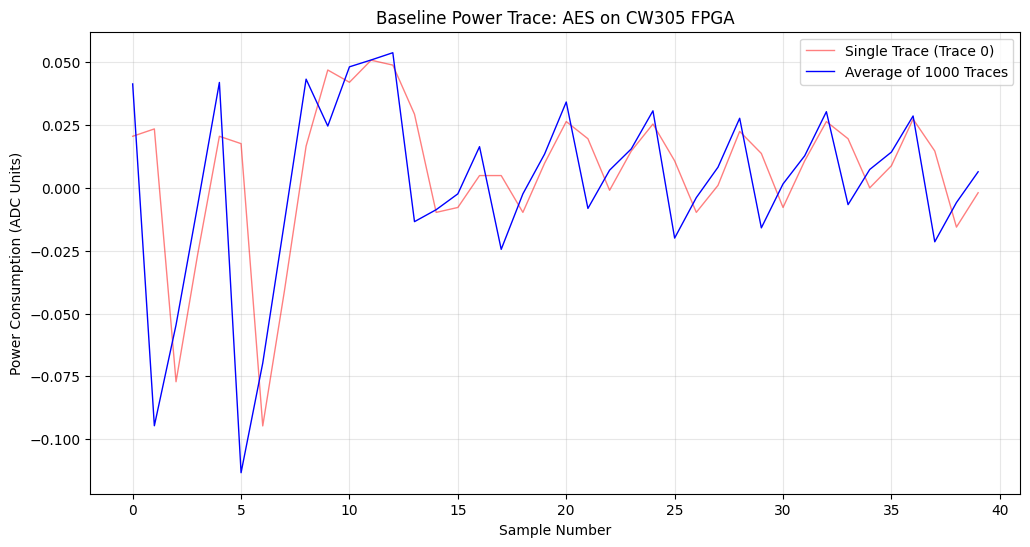

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure your normal_traces list has data
if not normal_traces:
    print("Error: No traces were collected. Run the 'Normal Trace Collection' loop first.")
else:
    # --- PLOT SETUP ---
    
    # 1. Get the first trace as a baseline
    first_trace = np.array(normal_traces[0])
    
    # 2. Get the average of all collected traces (provides a cleaner view)
    average_trace = np.average(normal_traces, axis=0)
    
    # --- PLOTTING ---
    plt.figure(figsize=(12, 6))
    
    # Plot the first collected trace
    plt.plot(first_trace, label="Single Trace (Trace 0)", color='red', alpha=0.5,linewidth=1)
    
    # Plot the average trace
    plt.plot(average_trace, label=f"Average of {len(normal_traces)} Traces", color='blue', linewidth=1)
    
    plt.title("Baseline Power Trace: AES on CW305 FPGA")
    plt.xlabel("Sample Number")
    plt.ylabel("Power Consumption (ADC Units)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [8]:
#Glitch Setup 
scope.io.hs2 = "glitch"
scope.glitch.clk_src = 'clkgen'
scope.glitch.ext_offset = 0
scope.glitch.width = 5.078125
scope.glitch.offset = -1.953125
scope.glitch.trigger_src = "continuous" #change this depending on glitching desired
#target.api.setParameter(['Glitch Module', 'Output Mode', 'Clock XORd'])

In [9]:

for i in range(10):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    
    if scope.capture():
        print("Timeout – no trigger seen")
        continue


    if ok and out != EXPECTED_CIPHERTEXT:
        print("REAL GLITCH FAULT FOUND:", out.hex())
    else:
        print("normal",out.hex())


normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de


In [10]:
## --- 2. CAPTURE Glitched TRACES ---
print("\n--- Collecting Traces after introducing Faults---")
# Storage for the normal traces
glitched_traces = []

for i in range(NUM_NORMAL_TRACES):
    scope.arm()
    output, success = run_aes(target, PLAINTEXT, KEY)
    
    if scope.capture():
        print(f"Timeout occurred on trace {i}")
        continue

    trace = scope.get_last_trace()
    glitched_traces.append(trace)
    
    # Verify the output is the expected ciphertext
    #if output == EXPECTED_CIPHERTEXT:
        #print(f"Trace {i}: Success, Output: {output.hex()}")
    #else:
        #print(f"Trace {i}: FAIL, Output: {output.hex() if output else 'N/A'}")

    if output != EXPECTED_CIPHERTEXT:
        print(f"Trace {i}: FAIL, Output: {output.hex() if output else 'N/A'}")
        
print(f"After glitching trace collection complete. Collected {len(glitched_traces)} After Glitching traces.")



--- Collecting Traces after introducing Faults---
After glitching trace collection complete. Collected 10000 After Glitching traces.


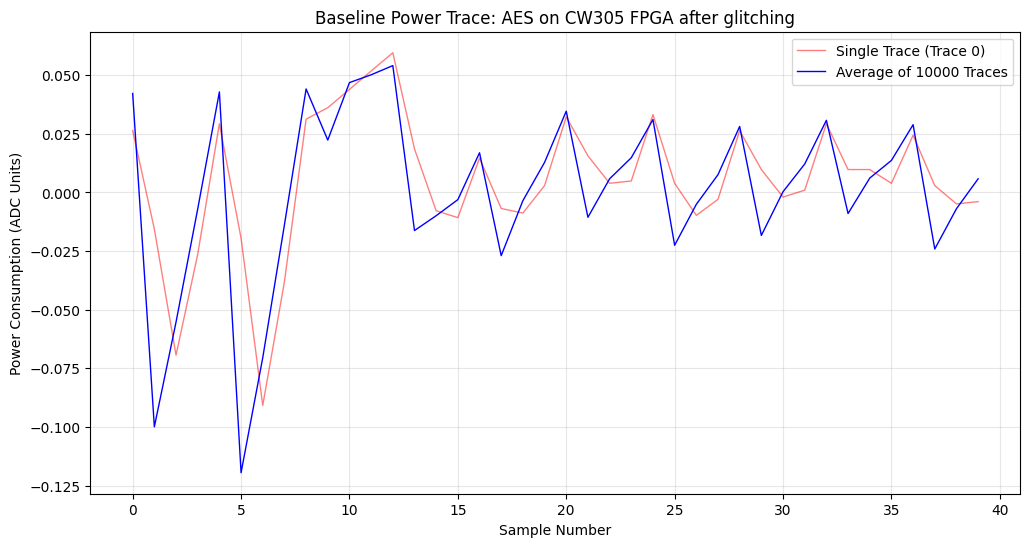

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure your normal_traces list has data
if not glitched_traces:
    print("Error: No traces were collected. Run the 'Glitched Trace Collection' loop first.")
else:
    # --- PLOT SETUP ---
    
    # 1. Get the first trace as a baseline
    first_trace = np.array(glitched_traces[0])
    
    # 2. Get the average of all collected traces (provides a cleaner view)
    average_trace = np.average(glitched_traces, axis=0)
    
    # --- PLOTTING ---
    plt.figure(figsize=(12, 6))
    
    # Plot the first collected trace
    plt.plot(first_trace, label="Single Trace (Trace 0)", color='red', alpha=0.5,linewidth=1)
    
    # Plot the average trace
    plt.plot(average_trace, label=f"Average of {len(glitched_traces)} Traces", color='blue', linewidth=1)
    
    plt.title("Baseline Power Trace: AES on CW305 FPGA after glitching")
    plt.xlabel("Sample Number")
    plt.ylabel("Power Consumption (ADC Units)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [18]:
def diff_bytes(a, b):
    return sum(x != y for x, y in zip(a, b))
N = 10000
faults = 0
hist = {}
for i in range(N):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    if scope.capture() or (not ok) or out is None:
        continue

    d = diff_bytes(out, EXPECTED_CIPHERTEXT)
    hist[d] = hist.get(d, 0) + 1
    if d != 0:
        faults += 1
print("Fault rate:", faults / N)
print("Diff-bytes histogram:", dict(sorted(hist.items())))

Fault rate: 0.0278
Diff-bytes histogram: {0: 9722, 6: 1, 16: 277}


In [19]:
from collections import Counter

pos_ctr = Counter()

for i in range(N):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    if scope.capture() or (not ok) or out is None:
        continue
    if out == EXPECTED_CIPHERTEXT:
        continue
    for idx, (a,b) in enumerate(zip(out, EXPECTED_CIPHERTEXT)):
        if a != b:
            pos_ctr[idx] += 1

print("Byte position fault counts (0..15):")
print(dict(sorted(pos_ctr.items())))


Byte position fault counts (0..15):
{0: 364, 1: 364, 2: 364, 3: 364, 4: 364, 5: 364, 6: 364, 7: 364, 8: 364, 9: 364, 10: 364, 11: 364, 12: 364, 13: 364, 14: 364, 15: 364}


In [3]:
def run_aes(target, plaintext, key):
    target.set_key(key)
    target.simpleserial_write('p', plaintext)
    # The target.go() is handled by simpleserial_write for the CW305 target
    
    # Read the output from the target
    try:
        response = target.simpleserial_read('r', 16)
        if len(response) == 16:
            return response, True
        else:
            return None, False
    except Exception as e:
        print(f"Target read error: {e}")
        return None, False

In [2]:
print(f"Target VCC-INT set to: {target.vccint_get()}V")

# Setup PLL1 on CW305 (assuming 10MHz external clock is provided by CW-Lite)
target.pll.pll_outfreq_set(10E6, 1) # Set PLL1 to 50 MHz (common FPGA clock)
target.pll.pll_enable_set(True)
target.pll.pll_outenable_set(True, 1)

# --- CONFIGURE CW-LITE SCOPE FOR POWER TRACING ---
# Use the clock generated by the CW305 (EXTCLK) as the ADC clock source
scope.default_setup()
scope.clock.adc_src = "extclk_x4" # Use 4x the target clock for sampling
scope.adc.samples = 400 # Number of samples to capture per trace
scope.adc.offset = 0
scope.gain.gain = 25
scope.adc.presamples = 0
scope.adc.basic_mode = "falling_edge"
scope.trigger.triggers = 'tio4' # FPGA trigger pin TIO4 is used to arm the scope/glitch
scope.io.tio1 = "serial_tx"
scope.io.tio2 = "serial_rx"
scope.io.tio3 = "high_z" # Not used
scope.io.tio4 = "high_z" # Used for trigger, set by FPGA





import time
for i in range(5):
    scope.clock.reset_adc()
    time.sleep(1)
    if scope.clock.adc_locked:
        break 
assert (scope.clock.adc_locked), "ADC failed to lock"

Target VCC-INT set to: 1.0V
scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 2519970607                to 2532971202               
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 96000000                  to 29538459                 
scope.clock.adc_rate                     changed from 96000000.0                to 29538459.0       

In [4]:
#scope.io.glitch_lp = False     # CW305 uses LP glitch
#scope.io.glitch_hp = False
for i in range(10):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    
    if scope.capture():
        print("Timeout – no trigger seen")
        continue


    if ok and out != EXPECTED_CIPHERTEXT:
        print("REAL GLITCH FAULT FOUND:", out.hex())
        break
    else:
        print("normal",out.hex())


normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de


In [5]:
## --- 2. CAPTURE NORMAL TRACES ---
print("\n--- Collecting Normal Traces ---")
# Storage for the normal traces
normal_traces = []

# Function to run the AES encryption on the target
def run_aes(target, plaintext, key):
    target.set_key(key)
    target.simpleserial_write('p', plaintext)
    # The target.go() is handled by simpleserial_write for the CW305 target
    
    # Read the output from the target
    try:
        response = target.simpleserial_read('r', 16)
        if len(response) == 16:
            return response, True
        else:
            return None, False
    except Exception as e:
        print(f"Target read error: {e}")
        return None, False

for i in range(NUM_NORMAL_TRACES):
    scope.arm()
    output, success = run_aes(target, PLAINTEXT, KEY)
    
    if scope.capture():
        print(f"Timeout occurred on trace {i}")
        continue

    trace = scope.get_last_trace()
    normal_traces.append(trace)
    
    # Verify the output is the expected ciphertext
    #if output == EXPECTED_CIPHERTEXT:
        #print(f"Trace {i}: Success, Output: {output.hex()}")
    #else:
        #print(f"Trace {i}: FAIL, Output: {output.hex() if output else 'N/A'}")

    if output != EXPECTED_CIPHERTEXT:
        print(f"Trace {i}: FAIL, Output: {output.hex() if output else 'N/A'}")
        
print(f"Baseline trace collection complete. Collected {len(normal_traces)} good traces.")



--- Collecting Normal Traces ---
Baseline trace collection complete. Collected 10000 good traces.


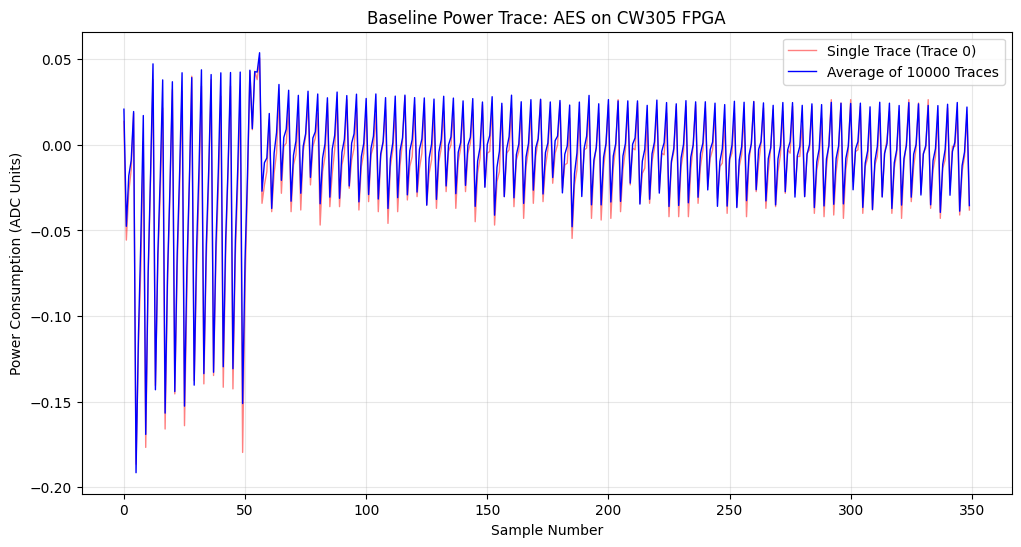

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure your normal_traces list has data
if not normal_traces:
    print("Error: No traces were collected. Run the 'Normal Trace Collection' loop first.")
else:
    # --- PLOT SETUP ---
    
    # 1. Get the first trace as a baseline
    first_trace = np.array(normal_traces[0])
    
    # 2. Get the average of all collected traces (provides a cleaner view)
    average_trace = np.average(normal_traces, axis=0)
    
    # --- PLOTTING ---
    plt.figure(figsize=(12, 6))
    
    # Plot the first collected trace
    plt.plot(first_trace, label="Single Trace (Trace 0)", color='red', alpha=0.5,linewidth=1)
    
    # Plot the average trace
    plt.plot(average_trace, label=f"Average of {len(normal_traces)} Traces", color='blue', linewidth=1)
    
    plt.title("Baseline Power Trace: AES on CW305 FPGA")
    plt.xlabel("Sample Number")
    plt.ylabel("Power Consumption (ADC Units)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [5]:
import time
import numpy as np
from collections import Counter

EXPECTED = bytes(EXPECTED_CIPHERTEXT)

def diff_bytes(a, b):
    return sum(x != y for x, y in zip(a, b))

def one_run():
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    if scope.capture() or (not ok) or out is None:
        return None
    return out

def eval_setting(trials=300):
    """Return: total, faults, fault_rate, avg_diff, top3_masks"""
    total = 0
    faults = 0
    diffs = []
    mask_ctr = Counter()

    for _ in range(trials):
        out = one_run()
        if out is None:
            continue
        total += 1
        d = diff_bytes(out, EXPECTED)
        diffs.append(d)
        if d != 0:
            faults += 1
            m = bytes([x ^ y for x, y in zip(out, EXPECTED)]).hex()
            mask_ctr[m] += 1

    if total == 0:
        return 0, 0, 0.0, 0.0, []
    return total, faults, faults/total, sum(diffs)/len(diffs), mask_ctr.most_common(3)



In [12]:
# Make sure baseline VCC is safe
target.vccint_set(1.0)
time.sleep(0.2)

# Enable voltage glitch path for CW305
scope.io.glitch_lp = True
scope.io.glitch_hp = False
scope.glitch.repeat = 1
scope.glitch.trigger_src = 'ext_single'


In [13]:
import numpy as np
import time
import csv
from collections import Counter

EXPECTED = bytes(EXPECTED_CIPHERTEXT)

def diff_bytes(a, b):
    return sum(x != y for x, y in zip(a, b))

def one_run():
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    if scope.capture() or (not ok) or out is None:
        return None
    return out

def eval_setting(trials=80):
    total = 0
    faults = 0
    diffs = []
    masks = Counter()

    for _ in range(trials):
        out = one_run()
        if out is None:
            continue
        total += 1
        d = diff_bytes(out, EXPECTED)
        diffs.append(d)
        if d != 0:
            faults += 1
            m = bytes([x ^ y for x, y in zip(out, EXPECTED)]).hex()
            masks[m] += 1

    if total == 0:
        return 0, 0.0, 0.0, 0, []
    fault_rate = faults / total
    avg_diff = sum(diffs) / len(diffs)
    unique_masks = len(masks)
    top3 = masks.most_common(3)
    return total, fault_rate, avg_diff, unique_masks, top3

# --- FULL RANGE SETTINGS ---
target.vccint_set(1.0)   # mapping at clean baseline
time.sleep(0.2)

scope.io.glitch_lp = True
scope.io.glitch_hp = False
scope.glitch.repeat = 1
scope.glitch.trigger_src = 'ext_single'

# Allowed offset range from hardware:
off_lo = scope.glitch.cwg._min_offset
off_hi = scope.glitch.cwg._max_offset

# Dense offsets (e.g., 81 points across full range)
offsets = np.linspace(-10, 40, 20)

# Dense widths: cover very small widths too (log spaced)
# Tune endpoints if needed; these are safe to try.
widths = np.geomspace(0.5, 40.0, 40)  # 40 widths from 0.001 to 1.0

# Optional: avoid exactly 0 offset if you get the warning
def sanitize_offset(x):
    return 0.5 if abs(x) < 1e-12 else float(x)

results = []
csv_path = "grid_sweep_results.csv"

print(f"Sweeping {len(widths)} widths × {len(offsets)} offsets = {len(widths)*len(offsets)} points")
print("Saving to:", csv_path)

with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["width", "offset", "total", "fault_rate", "avg_diff", "unique_masks", "top1", "top1_count", "top2", "top2_count", "top3", "top3_count"])

    for wi, w in enumerate(widths):
        scope.glitch.width = float(w)
        time.sleep(0.01)

        for oi, off in enumerate(offsets):
            off = sanitize_offset(off)
            scope.glitch.offset = float(off)
            time.sleep(0.005)

            total, fr, avgd, uniq, top3 = eval_setting(trials=80)

            # pad top3
            padded = top3 + [("","")] * (3 - len(top3))
            (m1,c1),(m2,c2),(m3,c3) = padded[:3]

            writer.writerow([float(w), float(off), total, fr, avgd, uniq, m1, c1, m2, c2, m3, c3])
            f.flush()

            # console progress (light)
            if (oi % 20 == 0):
                print(f"w[{wi+1}/{len(widths)}]={w:.4f}  off={off:7.2f}  fr={fr:.2f}  avgd={avgd:.2f}  uniq={uniq}")

print("Done.")


Sweeping 40 widths × 20 offsets = 800 points
Saving to: grid_sweep_results.csv
w[1/40]=0.5000  off= -10.00  fr=0.00  avgd=0.00  uniq=0
w[2/40]=0.5595  off= -10.00  fr=0.00  avgd=0.00  uniq=0
w[3/40]=0.6260  off= -10.00  fr=0.00  avgd=0.00  uniq=0
w[4/40]=0.7004  off= -10.00  fr=0.00  avgd=0.00  uniq=0
w[5/40]=0.7837  off= -10.00  fr=0.00  avgd=0.00  uniq=0
w[6/40]=0.8769  off= -10.00  fr=0.00  avgd=0.00  uniq=0
w[7/40]=0.9812  off= -10.00  fr=0.00  avgd=0.00  uniq=0
w[8/40]=1.0979  off= -10.00  fr=0.00  avgd=0.00  uniq=0
w[9/40]=1.2284  off= -10.00  fr=0.00  avgd=0.00  uniq=0
w[10/40]=1.3745  off= -10.00  fr=0.00  avgd=0.00  uniq=0
w[11/40]=1.5379  off= -10.00  fr=0.00  avgd=0.00  uniq=0
w[12/40]=1.7208  off= -10.00  fr=0.00  avgd=0.00  uniq=0
w[13/40]=1.9255  off= -10.00  fr=0.00  avgd=0.00  uniq=0
w[14/40]=2.1544  off= -10.00  fr=0.00  avgd=0.00  uniq=0
w[15/40]=2.4106  off= -10.00  fr=0.00  avgd=0.00  uniq=0
w[16/40]=2.6973  off= -10.00  fr=0.00  avgd=0.00  uniq=0
w[17/40]=3.0180  o

In [7]:
print(hasattr(scope.glitch, "ext_offset"))
print(scope.glitch)
print("offset:", scope.glitch.offset)
print("width:", scope.glitch.width)



True
clk_src     = target
mmcm_locked = True
width       = 30.078125
width_fine  = 0
offset      = 39.84375
offset_fine = 0
trigger_src = ext_single
arm_timing  = after_scope
ext_offset  = 0
repeat      = 1
output      = clock_xor

offset: 39.84375
width: 30.078125


In [5]:
# Enable glitch path
scope.io.glitch_lp = True     # CW305 uses LP glitch
scope.io.glitch_hp = False

scope.glitch.repeat = 1
scope.glitch.trigger_src = 'ext_single'  # standard

scope.glitch.width  = 2.0     # small
scope.glitch.offset = 20.0    # early, but not extreme

for i in range(10):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)

    if scope.capture():
        continue

    if ok and out != EXPECTED_CIPHERTEXT:
        print("REAL GLITCH FAULT FOUND:", out.hex())
        break
    else:
        print("normal",out.hex())


normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de


In [6]:
# Enable glitch path
scope.io.glitch_lp = True     # CW305 uses LP glitch
scope.io.glitch_hp = False
scope.glitch.repeat = 1
scope.glitch.trigger_src = 'ext_single'  # standard
scope.glitch.width  = 2.0
scope.glitch.offset = 20.0
for i in range(10):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    
    if scope.capture():
        print("Timeout – no trigger seen")
        continue
    if ok and out != EXPECTED_CIPHERTEXT:
        print("REAL GLITCH FAULT FOUND:", out.hex())
    else:
        print("normal",out.hex())

normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de


In [12]:
def diff_bytes(a, b):
    return sum(x != y for x, y in zip(a, b))
N = 1000
faults = 0
hist = {}
for i in range(N):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    if scope.capture() or (not ok) or out is None:
        continue

    d = diff_bytes(out, EXPECTED_CIPHERTEXT)
    hist[d] = hist.get(d, 0) + 1
    if d != 0:
        faults += 1
print("Fault rate:", faults / N)
print("Diff-bytes histogram:", dict(sorted(hist.items())))

Fault rate: 0.0
Diff-bytes histogram: {0: 1000}


In [19]:
from collections import Counter

pos_ctr = Counter()

for i in range(N):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    if scope.capture() or (not ok) or out is None:
        continue
    if out == EXPECTED_CIPHERTEXT:
        continue
    for idx, (a,b) in enumerate(zip(out, EXPECTED_CIPHERTEXT)):
        if a != b:
            pos_ctr[idx] += 1

print("Byte position fault counts (0..15):")
print(dict(sorted(pos_ctr.items())))


Byte position fault counts (0..15):
{0: 174, 1: 142, 2: 131, 3: 124, 4: 120, 5: 132, 6: 123, 7: 141, 9: 135, 10: 149, 11: 130, 12: 50, 13: 60, 14: 146, 15: 125}


In [8]:
mask_ctr = Counter()

for i in range(N):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    if scope.capture() or (not ok) or out is None:
        continue
    if out == bytes(EXPECTED_CIPHERTEXT):
        continue
    masks = bytes([x ^ y for x,y in zip(out, EXPECTED_CIPHERTEXT)])
    mask_ctr[masks.hex()] += 1

print("Top 10 XOR masks:")
for m,c in mask_ctr.most_common(10):
    print(c, m)


Top 10 XOR masks:
113 00000000000000200000000000000000
66 02000000000000000023000000000000
60 00002200000000000000000200000000
59 00000000000003000000000000000000
50 00000000200000000000000000010002
40 02000000000000000000000000000000
35 00000000002100000000000000002300
34 00000020000000000000000001000000
30 00002200000000000000220000000000
28 00230000000000000000220000000000


In [11]:
for off in np.linspace(-40, 40, 90):
    scope.glitch.offset = off
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    scope.capture()
    if ok and out != EXPECTED_CIPHERTEXT:
        print("FAULT at offset", off, out.hex())


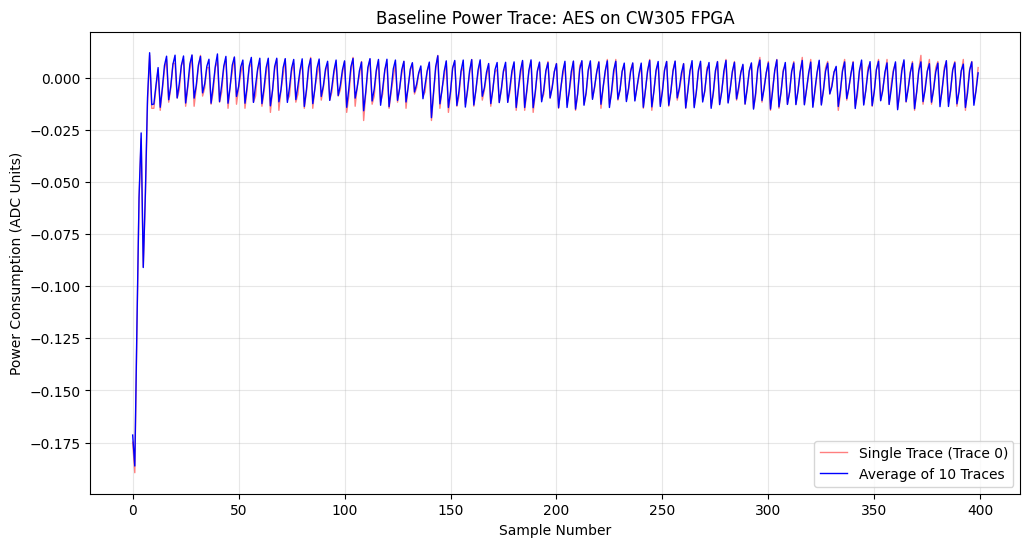

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure your normal_traces list has data
if not normal_traces:
    print("Error: No traces were collected. Run the 'Normal Trace Collection' loop first.")
else:
    # --- PLOT SETUP ---
    
    # 1. Get the first trace as a baseline
    first_trace = np.array(normal_traces[0])
    
    # 2. Get the average of all collected traces (provides a cleaner view)
    average_trace = np.average(normal_traces, axis=0)
    
    # --- PLOTTING ---
    plt.figure(figsize=(12, 6))
    
    # Plot the first collected trace
    plt.plot(first_trace, label="Single Trace (Trace 0)", color='red', alpha=0.5,linewidth=1)
    
    # Plot the average trace
    plt.plot(average_trace, label=f"Average of {len(normal_traces)} Traces", color='blue', linewidth=1)
    
    plt.title("Baseline Power Trace: AES on CW305 FPGA")
    plt.xlabel("Sample Number")
    plt.ylabel("Power Consumption (ADC Units)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [8]:
glitched_results = []
successful_faults = 0
successful_params = []
# --- VCC_INT SWEEP DEFINITION ---
# Start safe (1.0V) and go down to crash point (0.70V), in 10 steps
VCC_INT_TARGET = 1.0
# Sweep the range just before Round 10 to catch Round 9
OFFSETS = np.linspace(4.0, 49, 80) 

# Keep VCC very low as you've confirmed VCC=0.87 is effective
VCC_SWEEP = np.linspace(1.0, 0.87, 1)
FIXED_WIDTH = 4
ATTEMPTS_PER_POINT = 1

print("\n--- Starting Nested VCC/Offset Sweep ---")
print(f"Total Attempts: {len(VCC_SWEEP) * len(OFFSETS) * ATTEMPTS_PER_POINT}")


for vcc in VCC_SWEEP:
    # 1. SET THE NEW VULNERABLE VOLTAGE
    target.vccint_set(vcc)
    scope.glitch.width = FIXED_WIDTH
    
    # 2. SWEEP OFFSET AT THIS VOLTAGE LEVEL
    for offset in OFFSETS:
        scope.glitch.offset = offset
        
        # 3. ATTEMPT GLITCH MULTIPLE TIMES
        for attempt in range(ATTEMPTS_PER_POINT):
            
            i = len(glitched_results) # Tracking total attempts
            
            scope.arm()
            output, success = run_aes(target, PLAINTEXT, KEY)

            # --- CRASH & REPROGRAM LOGIC ---
            if scope.capture():
                # Handle timeout/crash
                try:
                    target.fpga_write(BITSTREAM_FILEPATH)
                except:
                    pass
                # Log the crash for plotting later
                glitched_results.append({'result': 'TIMEOUT', 'vcc': vcc, 'offset': offset})
                print(f"Attempt {i}: TIMEOUT (VCC={vcc:.2f}, o={offset:.1f}). Reprogrammed.")
                continue
            
            # --- FAULT DETECTION LOGIC ---
            output_hex = output.hex() if output else "N/A"
            expected_hex = EXPECTED_CIPHERTEXT.hex()
            
            if output_hex != expected_hex:
                result = 'FAULT'
                successful_faults += 1
            else:
                result = 'NORMAL'
                
            # Log the result
            glitched_results.append({'result': result, 'vcc': vcc, 'offset': offset, 'output': output_hex})
            
            # --- MODIFIED PRINT STATEMENT TO SHOW OUTPUT ---
            if result == 'FAULT':
                print(f"Attempt {i}: **FAULT** (VCC={vcc:.2f}, o={offset:.1f}) OUTPUT: {output_hex}")
                successful_params.append({'vcc': vcc, 'offset': offset, 'output': output_hex})
            else:
                # Prints the correct output for monitoring
                print(f"Attempt {i}: Normal (VCC={vcc:.2f}, o={offset:.1f}) OUTPUT: {output_hex}")


--- Starting Nested VCC/Offset Sweep ---
Total Attempts: 80
Attempt 0: Normal (VCC=1.00, o=4.0) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 1: Normal (VCC=1.00, o=4.6) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 2: Normal (VCC=1.00, o=5.1) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 3: Normal (VCC=1.00, o=5.7) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 4: Normal (VCC=1.00, o=6.3) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 5: Normal (VCC=1.00, o=6.8) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 6: Normal (VCC=1.00, o=7.4) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 7: Normal (VCC=1.00, o=8.0) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 8: Normal (VCC=1.00, o=8.6) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 9: Normal (VCC=1.00, o=9.1) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 10: Normal (VCC=1.00, o=9.7) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 11: Normal (VCC=1.00, o=10.3) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 12: 

In [17]:
# --- FINALIZED SWEET SPOT PARAMETERS ---
VCC_FINAL = 0.87      # Stable fault voltage
OFFSET_FINAL = 38.9 # Offset that consistently yields the fault
WIDTH_FINAL = 4.0     # Finalized width

# --- INITIALIZE FOR SINGLE ATTEMPT ---
glitched_trace_for_plot = None
attempt_result = None

target.vccint_set(VCC_FINAL)
scope.glitch.width = WIDTH_FINAL
scope.glitch.offset = OFFSET_FINAL
scope.glitch.repeat = 1

print(f"\n--- COLLECTING SINGLE FAULT TRACE at VCC={VCC_FINAL}V, Offset={OFFSET_FINAL} ---")

# Run loop until a successful fault trace is collected (max 10 attempts for stability)
for i in range(10): 
    scope.arm()
    output, success = run_aes(target, PLAINTEXT, KEY)

    if scope.capture():
        # Handle crash (reprogram if needed)
        try:
            target.fpga_write(BITSTREAM_FILEPATH)
            print(f"Attempt {i}: TIMEOUT. Reprogrammed.")
        except:
            pass
        continue

    output_hex = output.hex()
    expected_hex = EXPECTED_CIPHERTEXT.hex()
    
    if output_hex != expected_hex and success:
        # A true fault occurred, and communication was successful
        glitched_trace_for_plot = scope.get_last_trace()
        attempt_result = output_hex
        print(f"SUCCESS: Fault Trace Collected. Output: {attempt_result}")
    else:
        # Normal run, not crash. Continue attempting.
        print(f"Attempt {i}: Normal result. Re-attempting fault...")
        
# Set VCC-INT back to a safe level immediately
target.vccint_set(1.0)


--- COLLECTING SINGLE FAULT TRACE at VCC=0.87V, Offset=38.9 ---
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99ff8907b2e5e5ddd77de
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99ff8907b2e5e5ddd77de
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99fd8907b2e5e5ddd77de
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99ff8907b2e5e5ddd77de
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99ff8907b2e5e5ddd77de
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99ff8907b2e5e5ddd77de
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99ff8907b2e5e5ddd77de
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99ff8907b2e5e5ddd77de
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99ff8907b2e5e5ddd77de
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99ff8907b2e5e5ddd77de


In [10]:
import csv
import time

EXPECTED = EXPECTED_CIPHERTEXT  # bytes length 16

def num_diff_bytes(a, b):
    return sum(x != y for x, y in zip(a, b))

def xor_mask(a, b):
    return bytes([x ^ y for x, y in zip(a, b)])

def collect_10000_for_vcc(vcc, offset, width, N=10000, csv_path="aes_faults.csv",
                          save_fault_traces=False, max_fault_traces=50):
    # Apply settings
    target.vccint_set(vcc)
    scope.glitch.width = width
    scope.glitch.offset = offset
    scope.glitch.repeat = 1

    time.sleep(0.1)  # let rail settle

    fault_traces = []
    faults = 0
    timeouts = 0

    with open(csv_path, "a", newline="") as f:
        w = csv.writer(f)

        # Write header if file is empty
        if f.tell() == 0:
            w.writerow([
                "vcc","trial","status","success","ciphertext_hex",
                "is_faulty","num_diff_bytes","xor_mask_hex"
            ])

        for i in range(N):
            scope.arm()
            output, success = run_aes(target, PLAINTEXT, KEY)

            if scope.capture():
                timeouts += 1
                # Keep this lightweight; reprogram only if you truly need to.
                # If reprogram is necessary in your setup, keep it here:
                try:
                    target.fpga_write(BITSTREAM_FILEPATH)
                except Exception:
                    pass

                w.writerow([vcc, i, "TIMEOUT", 0, "", 0, "", ""])
                continue

            # If run_aes failed at comms layer, log it distinctly
            if not success or output is None or len(output) != 16:
                w.writerow([vcc, i, "BAD_COMM", int(success), "", 0, "", ""])
                continue

            is_faulty = int(output != EXPECTED)
            ndiff = num_diff_bytes(EXPECTED, output) if is_faulty else 0
            xmask = xor_mask(EXPECTED, output).hex() if is_faulty else "00"*16

            if is_faulty:
                faults += 1
                if save_fault_traces and len(fault_traces) < max_fault_traces:
                    fault_traces.append(scope.get_last_trace())

            w.writerow([vcc, i, "OK", 1, output.hex(), is_faulty, ndiff, xmask])

            # Print only occasionally (every 500) so it doesn’t slow you down
            if (i+1) % 500 == 0:
                print(f"VCC={vcc:.2f} | {i+1}/{N} | faults={faults} | timeouts={timeouts}")

    # Return VCC to safe level
    target.vccint_set(1.0)

    print(f"\nDONE VCC={vcc:.2f}: faults={faults}, timeouts={timeouts}, saved_traces={len(fault_traces)}")
    return fault_traces


In [3]:
target.set_key(key)
def run_aes(target, plaintext, key):
    target.simpleserial_write('p', plaintext)
    # The target.go() is handled by simpleserial_write for the CW305 target
    
    # Read the output from the target
    try:
        response = target.simpleserial_read('r', 16)
        if len(response) == 16:
            return response, True
        else:
            return None, False
    except Exception as e:
        print(f"Target read error: {e}")
        return None, False